# Wine Recommendation — K-Nearest Neighbors

**Objective:** given a wine a taster likes, recommend chemically similar wines from the catalog -- no other tasters or ratings needed.
**Method:** standardize each wine's 13 lab-measured chemical attributes, then use K-Nearest Neighbors (cosine similarity in that standardized space) to rank the catalog -- content-based, as opposed to the user-user collaborative filtering used elsewhere in this portfolio's recommendation work.

**Data:** the UCI Machine Learning Repository's Wine recognition dataset (Forina et al.) -- 178 wines grown in the same region of Italy from 3 different cultivars, each with 13 chemical measurements (alcohol, phenols, color intensity, proline, etc.). Bundled in scikit-learn via `sklearn.datasets.load_wine()`; exported to `data/wine.csv` here for a visible, portable copy.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

RESULT_DIR = "../result"
FIG_DIR = os.path.join(RESULT_DIR, "figures")
SLD_DIR = os.path.join(RESULT_DIR, "slides")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SLD_DIR, exist_ok=True)

## STEP 01 - Load Data

Real, sourced data: the UCI Wine dataset (Forina et al., 1991), the complete 178-record catalog -- not a synthetic sample.

In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["cultivar"] = wine.target
df["cultivar_name"] = df["cultivar"].map({i: name for i, name in enumerate(wine.target_names)})
df.index.name = "wine_id"

os.makedirs("../data", exist_ok=True)
df.to_csv("../data/wine.csv")

print(f"{len(df)} wines | {len(wine.feature_names)} chemical attributes | {df['cultivar'].nunique()} cultivars")
df.head()

178 wines | 13 chemical attributes | 3 cultivars


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar,cultivar_name
wine_id,,,,,,,,,,,,,,,
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## STEP 02 - Quick EDA

The 3 cultivars separate cleanly on some attributes (e.g. flavanoids, color intensity) and overlap on others -- exactly the kind of structure content-based similarity should be able to pick up on.

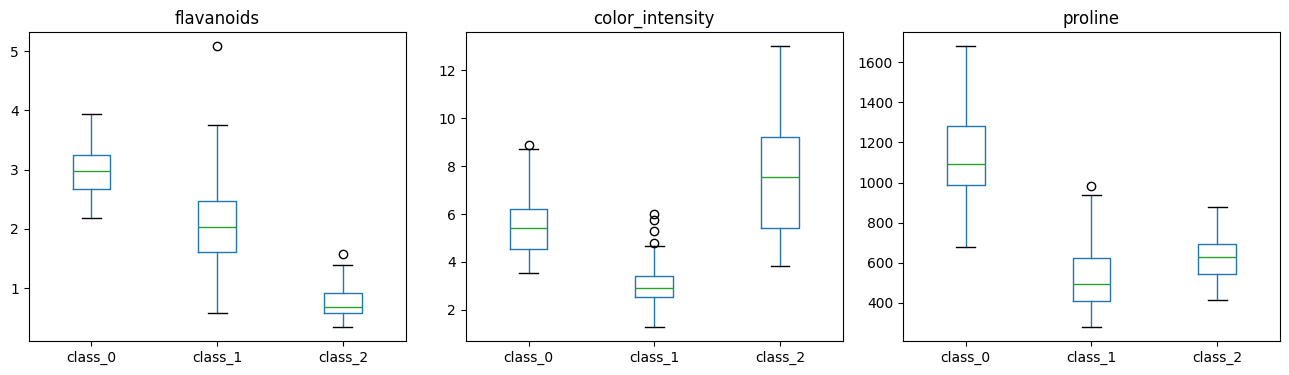

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["flavanoids", "color_intensity", "proline"]):
    df.boxplot(column=col, by="cultivar_name", ax=ax, grid=False)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "eda_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()

## STEP 03 - Standardize Features

The 13 attributes are on very different scales (proline is in the hundreds, hue is close to 1) -- standardizing to z-scores means the similarity metric weighs every attribute's *pattern*, not its raw magnitude.

In [4]:
import sys
sys.path.insert(0, ".")
from recommender import FEATURE_COLS, standardize_features, build_similarity_matrix, recommend, precision_at_k, precision_at_k_curve

X, scaler = standardize_features(df, FEATURE_COLS)
print(f"Standardized feature matrix: {X.shape}")

Standardized feature matrix: (178, 13)


## STEP 04 - K-Nearest Neighbors Similarity Matrix

Cosine similarity between every pair of wines in standardized feature space -- a 178x178 matrix where entry (i, j) is how alike wine i and wine j are. Ranking each wine's row gives its k nearest neighbors.

In [5]:
sim_matrix = build_similarity_matrix(X)
pd.DataFrame(sim_matrix, index=df.index, columns=df.index).iloc[:5, :5]

wine_id,0,1,2,3,4
wine_id,,,,,
0,1.000000,0.562260,0.672660,0.810789,0.487160
1,0.562260,1.000000,0.236842,0.487179,-0.157322
2,0.672660,0.236842,1.000000,0.746105,0.522739
3,0.810789,0.487179,0.746105,1.000000,0.404344
4,0.487160,-0.157322,0.522739,0.404344,1.000000


## STEP 05 - Recommend From a Reference Wine

Pick one wine as "the one a taster liked" and pull its top-5 most similar wines.

In [6]:
reference_id = 12
reference_label = f"Wine #{reference_id} (Cultivar {df.loc[reference_id, 'cultivar']})"

top5 = recommend(sim_matrix, df, reference_id, top_n=5)
print(f"Reference: {reference_label}")
top5[["cultivar_name", "similarity"] + FEATURE_COLS[:4]]

Reference: Wine #12 (Cultivar 0)


,cultivar_name,similarity,alcohol,malic_acid,ash,alcalinity_of_ash
wine_id,,,,,,
11,class_0,0.910898,14.12,1.48,2.32,16.8
51,class_0,0.891524,13.83,1.65,2.60,17.2
6,class_0,0.882615,14.39,1.87,2.45,14.6
14,class_0,0.861099,14.38,1.87,2.38,12.0
10,class_0,0.855441,14.10,2.16,2.30,18.0


## STEP 06 - Validate: Precision@k

For every wine in the catalog, check whether its top-k nearest neighbors actually share its cultivar (the real, known style) -- this is the honest test of whether "chemically similar" means anything, using ground truth the model never saw.

Average precision@5 across all 178 wines: 93.0%


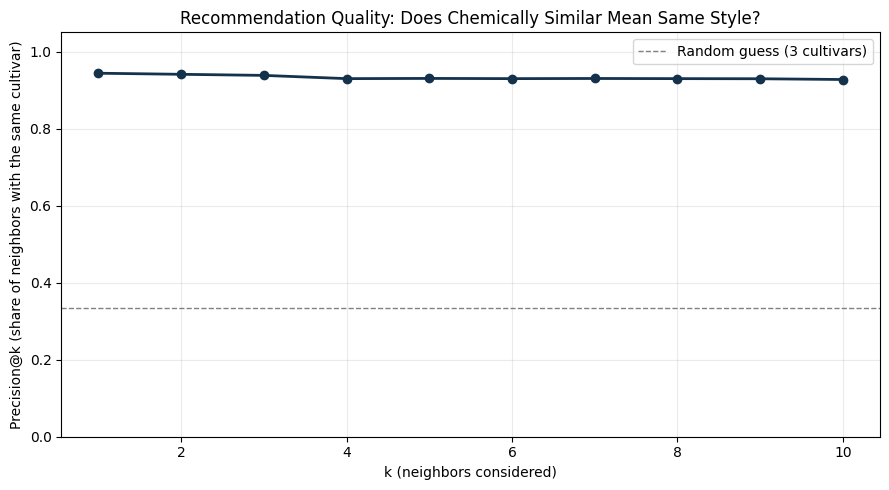

In [7]:
avg_p5, per_wine_p5 = precision_at_k(sim_matrix, df["cultivar"].values, k=5)
curve = precision_at_k_curve(sim_matrix, df["cultivar"].values, k_values=range(1, 11))
print(f"Average precision@5 across all {len(df)} wines: {avg_p5:.1%}")

plt.figure(figsize=(9, 5))
plt.plot(curve["k"], curve["precision_at_k"], marker="o", color="#14324B", lw=2)
plt.axhline(1/3, color="gray", ls="--", lw=1, label="Random guess (3 cultivars)")
plt.xlabel("k (neighbors considered)")
plt.ylabel("Precision@k (share of neighbors with the same cultivar)")
plt.title("Recommendation Quality: Does Chemically Similar Mean Same Style?")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
precision_curve_img = os.path.join(FIG_DIR, "precision_at_k.png")
plt.savefig(precision_curve_img, dpi=150, bbox_inches="tight")
plt.show()

## STEP 07 - Visualize the Chemical-Profile Match

A radar chart overlaying the reference wine's standardized chemical profile against its top-3 recommendations -- this is the visual answer to "why were these recommended": the shapes should trace closely together.

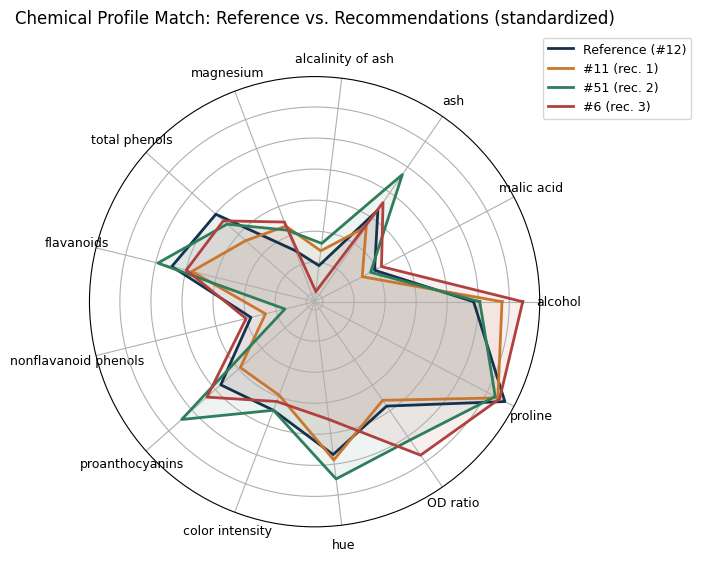

In [8]:
from math import pi

def radar_chart(df, feature_cols, wine_ids, labels, colors, save_path):
    angles = [n / float(len(feature_cols)) * 2 * pi for n in range(len(feature_cols))]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
    short_labels = [c.replace("_", " ").replace("od280/od315 of diluted wines", "OD ratio") for c in feature_cols]
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_yticklabels([])

    for wine_id, label, color in zip(wine_ids, labels, colors):
        values = df.loc[wine_id, feature_cols].values.tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, lw=2, label=label)
        ax.fill(angles, values, color=color, alpha=0.08)

    ax.set_title("Chemical Profile Match: Reference vs. Recommendations (standardized)", y=1.1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    return save_path

df_std = pd.DataFrame(X, index=df.index, columns=FEATURE_COLS)
top3_ids = top5.index[:3].tolist()
wine_ids = [reference_id] + top3_ids
labels = [f"Reference (#{reference_id})"] + [f"#{i} (rec. {rank+1})" for rank, i in enumerate(top3_ids)]
colors = ["#14324B", "#C9772F", "#2E7D5B", "#B0413E"]

radar_img = radar_chart(df_std, FEATURE_COLS, wine_ids, labels, colors,
                         os.path.join(FIG_DIR, "radar_chart.png"))
plt.show()

## STEP 08 - Similarity Landscape (PCA)

Where the reference wine and its recommendations sit relative to the full 178-wine catalog, projected to 2D. Tight clustering by color confirms the same signal precision@k measured numerically: content-based similarity tracks cultivar.

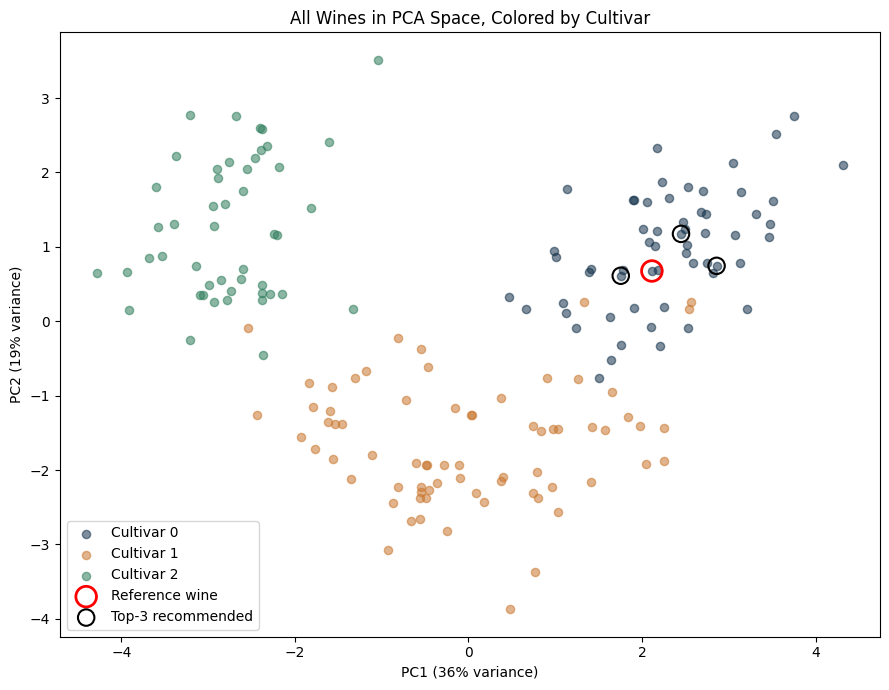

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
df_pca = pd.DataFrame(coords, index=df.index, columns=["pc1", "pc2"])

plt.figure(figsize=(9, 7))
palette = {0: "#14324B", 1: "#C9772F", 2: "#2E7D5B"}
for cultivar, group in df_pca.groupby(df["cultivar"]):
    plt.scatter(group["pc1"], group["pc2"], s=35, alpha=0.55,
                color=palette[cultivar], label=f"Cultivar {cultivar}")

plt.scatter(df_pca.loc[reference_id, "pc1"], df_pca.loc[reference_id, "pc2"],
            s=220, facecolors="none", edgecolors="red", linewidths=2, label="Reference wine")
plt.scatter(df_pca.loc[top3_ids, "pc1"], df_pca.loc[top3_ids, "pc2"],
            s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="Top-3 recommended")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
plt.title("All Wines in PCA Space, Colored by Cultivar")
plt.legend()
plt.tight_layout()
pca_img = os.path.join(FIG_DIR, "pca_landscape.png")
plt.savefig(pca_img, dpi=150, bbox_inches="tight")
plt.show()

## STEP 09 - Build the Executive Report

One summary slide, a precision@k validation slide, the sample recommendation walkthrough with its radar chart, and the full similarity landscape. Design lives in `report_builder.py`, same pattern as this portfolio's other executive reports, including the `result/figures/` + `result/slides/` output layout.

In [10]:
from report_builder import build_executive_report

recommended_rows = [
    (f"Wine #{i}", int(df.loc[i, "cultivar"]), f"{top5.loc[i, 'similarity']:.3f}")
    for i in top5.index
]

report_path = build_executive_report(
    n_wines=len(df), n_features=len(FEATURE_COLS), n_cultivars=df["cultivar"].nunique(),
    avg_precision_at5=avg_p5,
    precision_curve_img=precision_curve_img, radar_img=radar_img, pca_img=pca_img,
    reference_label=reference_label, recommended_rows=recommended_rows,
    output_dir=RESULT_DIR,
)
print(f"Report saved to {report_path}")

Report saved to ../result\slides\Executive_Wine_Recommendation_Report_20260830.pptx


## Conclusion

Precision@5 averages **93.0%** across all 178 wines -- nearly 3x the 33.3% a random guess would get with 3 cultivars -- and stays essentially flat (93% at k=1 down to 92.6% at k=10). Standardized chemical similarity is a genuinely strong proxy for "same style" here, not a coincidence of one lucky example.

The PCA landscape backs this up visually: the 3 cultivars form 3 mostly-separated clusters using just the first 2 principal components (36% + 19% = 55% of total variance), and the sample walkthrough's reference wine (#12) and its top-3 nearest neighbors all land inside the same cluster, tight together. The radar chart shows why at the feature level -- the reference and recommended wines trace nearly identical shapes across all 13 attributes, with the largest gaps on attributes that carry less weight in the overall similarity score.

**Bottom line:** K-Nearest Neighbors on lab-measured attributes is a solid content-based recommendation strategy when item features are rich and reliable, and it sidesteps collaborative filtering's cold-start problem entirely -- a brand-new wine with no ratings yet can still be recommended the moment its chemical profile is measured.